In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG16

(x_train,y_train),(x_test,y_test)=tf.keras.datasets.cifar10.load_data()

x_train=x_train[:5000].astype('float32')/255
y_train=y_train[:5000].flatten()
x_test=x_test[:1000].astype('float32')/255
y_test=y_test[:1000].flatten()

classes=['airplane','car','bird','cat','deer','dog','frog','horse','ship','truck']
print("Dataset loaded!")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1731s 10us/step
Dataset loaded!


In [ ]:
cnn=models.Sequential([
    layers.Input((32,32,3)),
    layers.Conv2D(16,3,activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(32,activation='relu'),
    layers.Dense(10,activation='softmax')
])

cnn.compile(optimizer='adam',loss='sparse_categorical_crossentropy',
            metrics=['accuracy'])

h1=cnn.fit(x_train,y_train,epochs=2,batch_size=128,validation_split=.2)

Epoch 1/2
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - accuracy: 0.1435 - loss: 2.2527 - val_accuracy: 0.1430 - val_loss: 2.2181
Epoch 2/2
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - accuracy: 0.1835 - loss: 2.1284 - val_accuracy: 0.1820 - val_loss: 2.1023


CNN Accuracy: 18.3 %
              precision    recall  f1-score   support

    airplane       0.00      0.00      0.00       103
         car       0.32      0.33      0.32        89
        bird       0.16      0.07      0.10       100
         cat       0.00      0.00      0.00       103
        deer       0.11      0.20      0.14        90
         dog       0.15      0.49      0.23        86
        frog       0.18      0.03      0.05       112
       horse       0.00      0.00      0.00       102
        ship       0.00      0.00      0.00       106
       truck       0.21      0.77      0.33       109

    accuracy                           0.18      1000
   macro avg       0.11      0.19      0.12      1000
weighted avg       0.11      0.18      0.11      1000



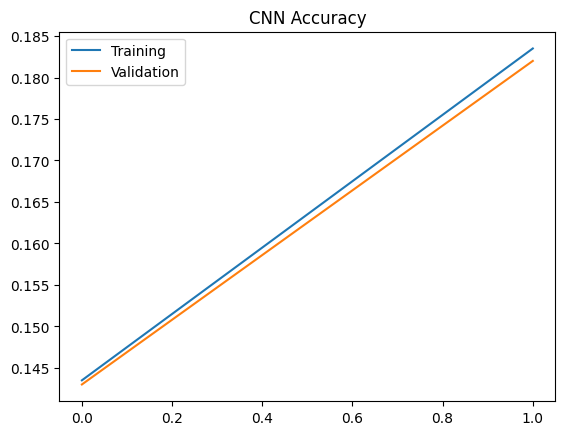

In [ ]:
a1=cnn.evaluate(x_test,y_test,verbose=0)[1]
p1=np.argmax(cnn.predict(x_test,verbose=0),axis=1)

print("CNN Accuracy:",round(a1*100,2),"%")
print(classification_report(y_test,p1,target_names=classes,zero_division=0))

plt.plot(h1.history['accuracy'],label='Training')
plt.plot(h1.history['val_accuracy'],label='Validation')
plt.title('CNN Accuracy'); plt.legend(); plt.show()

In [ ]:
base=VGG16(weights='imagenet',include_top=False,input_shape=(32,32,3))
base.trainable=False

# Extract features once to avoid repeatedly running VGG16 during training
f_train=base.predict(x_train,batch_size=128,verbose=1)
f_test=base.predict(x_test,batch_size=128,verbose=1)

vgg=models.Sequential([
    layers.Input(f_train.shape[1:]),
    layers.GlobalAveragePooling2D(),
    layers.Dense(32,activation='relu'),
    layers.Dense(10,activation='softmax')
])

vgg.compile(optimizer='adam',loss='sparse_categorical_crossentropy',
            metrics=['accuracy'])

h2=vgg.fit(f_train,y_train,epochs=2,batch_size=128,validation_split=.2)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
40/40 ━━━━━━━━━━━━━━━━━━━━ 64s 2s/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step
Epoch 1/2
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.1643 - loss: 2.2467 - val_accuracy: 0.2390 - val_loss: 2.0941
Epoch 2/2
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3122 - loss: 1.9617 - val_accuracy: 0.3300 - val_loss: 1.8915


VGG16 Accuracy: 36.8 %
              precision    recall  f1-score   support

    airplane       0.44      0.27      0.34       103
         car       0.31      0.38      0.34        89
        bird       0.33      0.37      0.35       100
         cat       0.33      0.41      0.36       103
        deer       0.31      0.29      0.30        90
         dog       0.33      0.24      0.28        86
        frog       0.36      0.44      0.40       112
       horse       0.57      0.20      0.29       102
        ship       0.46      0.69      0.55       106
       truck       0.36      0.35      0.35       109

    accuracy                           0.37      1000
   macro avg       0.38      0.36      0.36      1000
weighted avg       0.38      0.37      0.36      1000



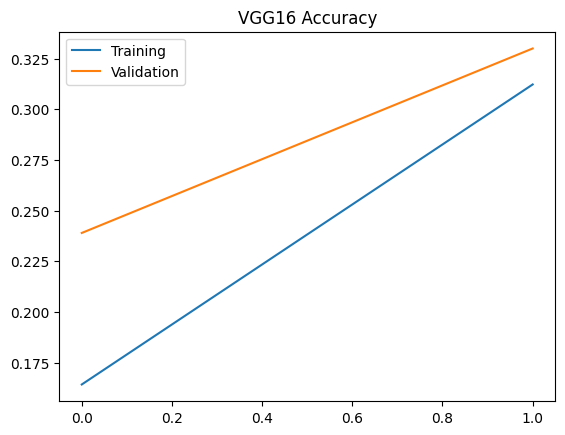

In [ ]:
a2=vgg.evaluate(f_test,y_test,verbose=0)[1]
p2=np.argmax(vgg.predict(f_test,verbose=0),axis=1)

print("VGG16 Accuracy:",round(a2*100,2),"%")
print(classification_report(y_test,p2,target_names=classes,zero_division=0))

plt.plot(h2.history['accuracy'],label='Training')
plt.plot(h2.history['val_accuracy'],label='Validation')
plt.title('VGG16 Accuracy'); plt.legend(); plt.show()

Custom CNN: 18.3 %
VGG16: 36.8 %


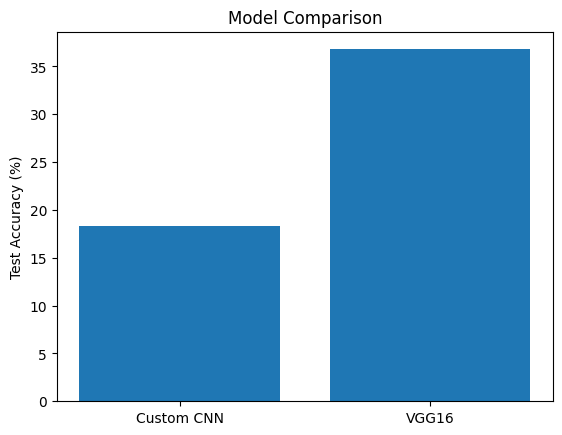

In [ ]:
print("Custom CNN:",round(a1*100,2),"%")
print("VGG16:",round(a2*100,2),"%")

plt.bar(['Custom CNN','VGG16'],[a1*100,a2*100])
plt.ylabel('Test Accuracy (%)')
plt.title('Model Comparison')
plt.show()